## Prediction code for fully random missing 3D cubes with size of $128 \times 128 \times 128$
<div style="text-align: right;">
<b>Authors:
    Yang Cui & Alessandro</b>
</div>

## import library

In [1]:
import warnings
import sys
import os
warnings.filterwarnings('ignore')
sys.path.append('../')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

import numpy as np
import matplotlib.pyplot as plt
import time
import cigsegy
from cigsegy import SegyNP
import pydrr as pd #pd: DRR

# from ufno_new import *
from ufno_new_1 import *
from utils import *
from eva_metrics import *
from pylops.basicoperators import *



# Check for CUDA availability and set the device
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

torch.manual_seed(0)

np.random.seed(0)

# Make a new dir to save figs
fig_path = "../figs/cube_test/full_random/"

# Create the directory, including any necessary parent directories
os.makedirs(fig_path, exist_ok=True)

## Load the testing data and pre-processing

<Figure size 600x600 with 0 Axes>

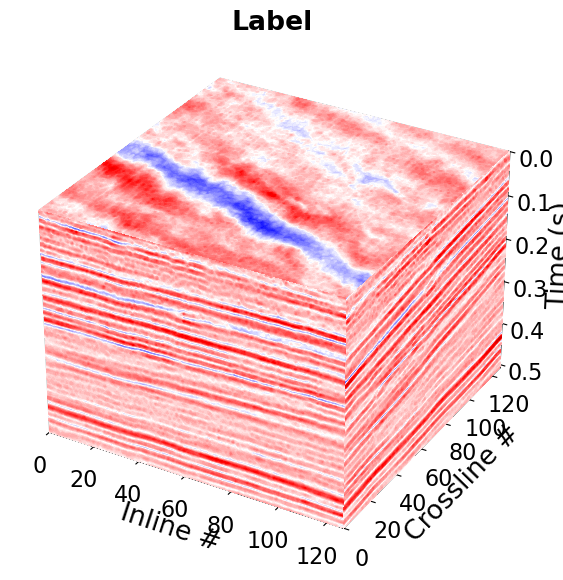

<Figure size 600x600 with 0 Axes>

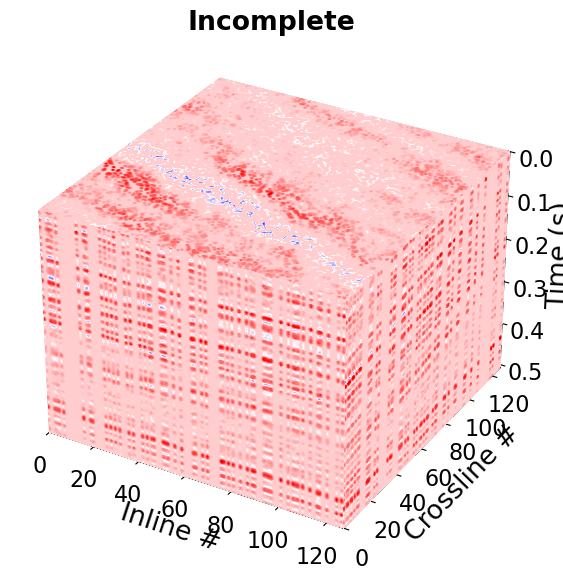

In [2]:
################################################################ 
# You need to change the ratio here!
################################################################



# Moomba_test_path = '../data/test_cubes/moomba_test_1.npy'
Moomba_test_path = '../data/test_cubes/F3_test_2.npy'
label = np.load(f'{Moomba_test_path}')
# label = label[:64, :64, :64]
cube_visual(label, dt=0.004, dz=1, xlabel="Inline #", ylabel="Crossline #", zlabel="Time (s)", 
            title='Label', save_path='False')

# ## build the input data
# [in1, in2, in3] = label.shape
# ## generate random mask
# iava, iavarec = irregular2(in1, in2, in3, perc_sub=ratio, seed=10)
# # Create restriction operator
# Rop = Restriction(dims=in1*in2*in3, iava=iava, dtype='float64')
# datamasked = Rop.H*Rop*label.ravel()
# mask = Rop.H*Rop*np.ones_like(label).ravel()
# mask = mask.reshape(in1, in2, in3)
# frand_mask_cube = label.T*mask
# test_data = frand_mask_cube.T
n1,n2,n3 = label.shape
ratio=0.35
mask=pd.genmask(label.reshape(n1,n2*n3,order='F'),ratio,'c',201415);
mask=mask.reshape(n1,n2,n3,order='F');

frand_mask_cube = label*mask

test_data = frand_mask_cube

cube_visual(frand_mask_cube, dt=0.004, dz=1, xlabel="Inline #", ylabel="Crossline #", zlabel="Time (s)",
            title='Incomplete', save_path='False')

## Prediction

In [3]:
# mode1 = 16
# mode2 = 16
# mode3 = 16
# # mode1 = 8
# # mode2 = 8
# # mode3 = 8
# width = 16


# def count_params(model):
#     """Count the total number of trainable parameters in the model."""
#     return sum(p.numel() for p in model.parameters() if p.requires_grad)


# model = Net3d(mode1, mode2, mode3, width).to(device)

# print(f"Model parameters: {count_params(model):,}")
# # model.load_state_dict(torch.load('../model/UFNO_3D_recon_all_modes16_width16_ep200_num900_all_types_new.pth'))

# # # Prediction
# # prediction = model(X)
# # output_data = prediction.cpu().detach().numpy()
# # output_data.shape

# # # np.save(f'./results/ufno_pred_moomba_ratio{1-ratio}_frandom.npy', output_data)
# # cube_visual(output_data, dt=0.004, dz=1, xlabel="Inline #", ylabel="Crossline #", zlabel="Time (s)", 
# #             title='Prediction', save_path='False')
# # cube_visual(label-output_data, dt=0.004, dz=1, xlabel="Inline #", ylabel="Crossline #", zlabel="Time (s)", 
# #             title='Difference', save_path='False')

<Figure size 600x600 with 0 Axes>

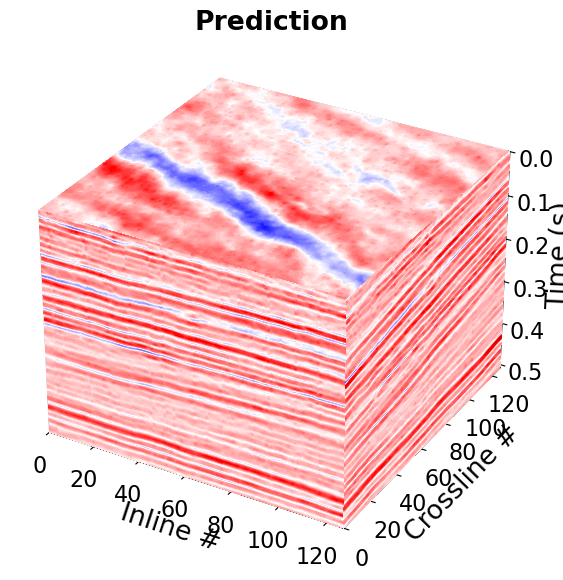

<Figure size 600x600 with 0 Axes>

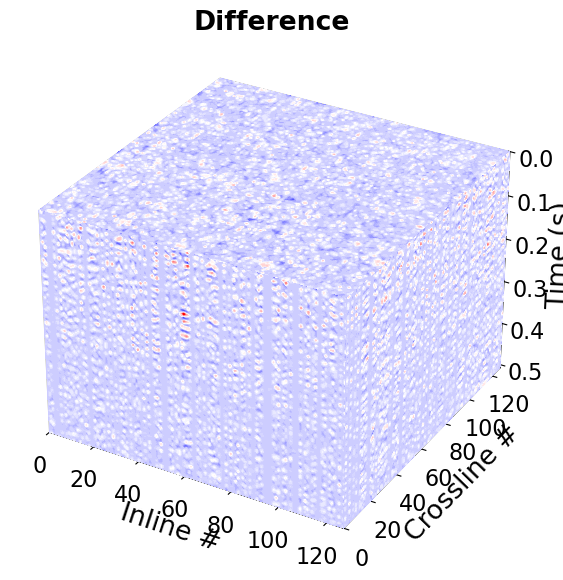

In [8]:
mode1 = 12
mode2 = 12
mode3 = 12
# mode1 = 8
# mode2 = 8
# mode3 = 8
width = 16

input_data = np.reshape(test_data, [1, test_data.shape[0], test_data.shape[1], test_data.shape[2]])
# input_data = input_data[:64, :64, :64]

# Convert to PyTorch tensors
X = torch.Tensor(input_data).unsqueeze(-1).to(device)


model = Net3d(mode1, mode2, mode3, width).to(device)
model.load_state_dict(torch.load('../model/UFNO_3D_recon_all_modes12_width16_ep250_num750_new_bn.pth'))

# Prediction
prediction = model(X)
output_data = prediction.cpu().detach().numpy()
output_data.shape

# np.save(f'./results/ufno_pred_moomba_ratio{1-ratio}_frandom.npy', output_data)
cube_visual(output_data, dt=0.004, dz=1, xlabel="Inline #", ylabel="Crossline #", zlabel="Time (s)", 
            title='Prediction', save_path='False')
cube_visual(label-output_data, dt=0.004, dz=1, xlabel="Inline #", ylabel="Crossline #", zlabel="Time (s)", 
            title='Difference', save_path='False')

In [9]:
# np.save(f'./results/ufno_pred_f3_2_ratio{1-ratio}_frandom.npy', output_data)

## Evaluation metrics

In [6]:
mse_0 = mse_cal(label, test_data)
mse_1 = mse_cal(label, output_data)
snr_0, psnr_0 = calculate_snr_psnr(label, test_data)
snr_1, psnr_1 = calculate_snr_psnr(label, output_data)
ssim_0 = compute_3d_ssim(label, test_data, patch_size=10)
ssim_1 = compute_3d_ssim(label, output_data, patch_size=10)
fd_0 = FrechetDistances(label, test_data)
fd_1 = FrechetDistances(label, output_data)


print(f'MSE incomplete: {mse_0:.3f}\tMSE recon: {mse_1:.3f}')
print(f'SNR incomplete: {snr_0:.3f} dB\tSNR recon: {snr_1:.3f} dB')
print(f'PSNR incomplete: {psnr_0:.3f} dB\tPSNR recon: {psnr_1:.3f} dB')
print(f'SSIM incomplete: {ssim_0:.3f} \t SSIM recon: {ssim_1:.3f}')
print(f'FD incomplete: {fd_0:.3f} \t FD recon: {fd_1:.3f}')

MSE incomplete: 0.576	MSE recon: 0.049
SNR incomplete: 1.872 dB	SNR recon: 12.554 dB
PSNR incomplete: 17.866 dB	PSNR recon: 28.548 dB
SSIM incomplete: 0.495 	 SSIM recon: 0.954
FD incomplete: 0.385 	 FD recon: 0.016


## 2D slices comparison

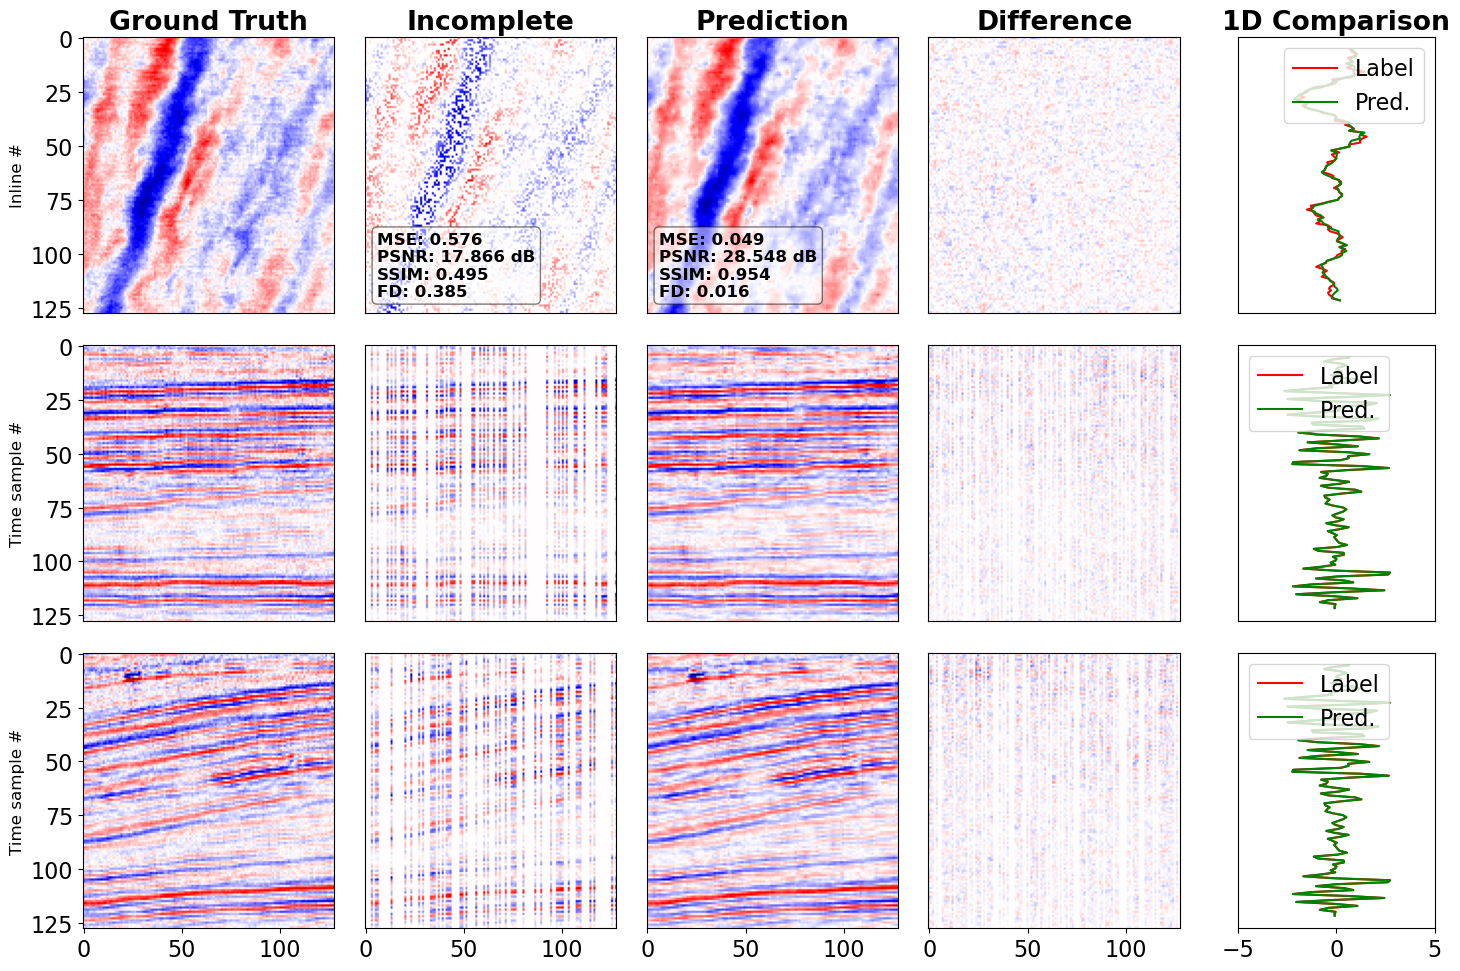

In [7]:
v = 5 # Set amplitude limit for color scaling
fig, axs = plt.subplots(3, 5, figsize=(15, 10))
time_num, xline_num, iline_num = 64, 100, 100
incomplete = test_data
prediction = output_data
trace_num = 100
# Time Slice
axs[0, 0].imshow(label [time_num, :, :], cmap='seismic', vmax=v, vmin=-v, aspect='auto')
axs[0, 0].set_title("Ground Truth", fontweight='bold')
axs[0, 0].set_ylabel('Inline #', fontsize=12)
# axs[0, 0].set_xlabel('Xline #', fontweight='bold', fontsize=12)

axs[0, 1].imshow(incomplete [time_num, :, :], cmap='seismic', vmax=v, vmin=-v, aspect='auto')
axs[0, 1].set_title("Incomplete", fontweight='bold')
axs[0, 1].text(0.05, 0.05, 
               f"MSE: {mse_0:.3f}\nPSNR: {psnr_0:.3f} dB\nSSIM: {ssim_0:.3f}\nFD: {fd_0:.3f}",
               ha='left', va='bottom', fontsize=12, fontweight='bold', transform=axs[0, 1].transAxes,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

axs[0, 2].imshow(prediction [time_num, :, :], cmap='seismic', vmax=v, vmin=-v, aspect='auto')
axs[0, 2].set_title("Prediction", fontweight='bold')
axs[0, 2].text(0.05, 0.05, 
               f"MSE: {mse_1:.3f}\nPSNR: {psnr_1:.3f} dB\nSSIM: {ssim_1:.3f}\nFD: {fd_1:.3f}",
               ha='left', va='bottom', fontsize=12, fontweight='bold', transform=axs[0, 2].transAxes,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

axs[0, 3].imshow(label [time_num, :, :] - prediction [time_num, :, :], cmap='seismic', vmax=v, vmin=-v, aspect='auto')
axs[0, 3].set_title("Difference", fontweight='bold')


trace_data_pred = prediction[time_num, trace_num, :]
trace_data_label = label[time_num, trace_num, :]

axs[0, 4].plot(trace_data_label, range(len(trace_data_label)), 'r', label="Label")
axs[0, 4].plot(trace_data_pred, range(len(trace_data_pred)), 'g', label="Pred.")
axs[0, 4].set_title("1D Comparison", fontweight='bold')
axs[0, 4].invert_yaxis()  # Flip the y-axis to match the seismic plot
axs[0, 4].set_xlim(-v, v)  # Limit x-axis range
axs[0, 4].set_aspect(0.1)  # Adjust the aspect ratio
axs[0, 4].legend()

# Inline Slice
axs[1, 0].imshow(label [:, :, xline_num], cmap='seismic', vmax=v, vmin=-v, aspect='auto')
axs[1, 0].set_ylabel('Time sample #', fontsize=12)
# axs[1, 0].set_xlabel('Inline #', fontweight='bold', fontsize=12)

axs[1, 1].imshow(incomplete [:, :, xline_num], cmap='seismic', vmax=v, vmin=-v, aspect='auto')

axs[1, 2].imshow(prediction [:, :, xline_num], cmap='seismic', vmax=v, vmin=-v, aspect='auto')

axs[1, 3].imshow(label [:, :, xline_num] - prediction [:, :, xline_num], cmap='seismic', vmax=v, vmin=-v, aspect='auto')


trace_data_pred = prediction[:, trace_num, xline_num]
trace_data_label = label[:, trace_num, xline_num]

axs[1, 4].plot(trace_data_label, range(len(trace_data_label)), 'r', label="Label")
axs[1, 4].plot(trace_data_pred, range(len(trace_data_pred)), 'g', label="Pred.")
axs[1, 4].invert_yaxis()  # Flip the y-axis to match the seismic plot
axs[1, 4].set_xlim(-v, v)  # Limit x-axis range
axs[1, 4].set_aspect(0.1)  # Adjust the aspect ratio
axs[1, 4].legend()

# Crossline Slice
axs[2, 0].imshow(label [:, iline_num, :], cmap='seismic', vmax=v, vmin=-v, aspect='auto')
axs[2, 0].set_ylabel('Time sample #', fontsize=12)

axs[2, 1].imshow(incomplete [:, iline_num, :], cmap='seismic', vmax=v, vmin=-v, aspect='auto')

axs[2, 2].imshow(prediction [:, iline_num, :], cmap='seismic', vmax=v, vmin=-v, aspect='auto')

axs[2, 3].imshow(label [:, iline_num, :] - prediction [:, iline_num, :], cmap='seismic', vmax=v, vmin=-v, aspect='auto')

trace_data_pred = prediction[:, iline_num, trace_num]
trace_data_label = label[:, iline_num, trace_num]

axs[2, 4].plot(trace_data_label, range(len(trace_data_label)), 'r', label="Label")
axs[2, 4].plot(trace_data_pred, range(len(trace_data_pred)), 'g', label="Pred.")
axs[2, 4].invert_yaxis()  # Flip the y-axis to match the seismic plot
axs[2, 4].set_xlim(-v, v)  # Limit x-axis range
axs[2, 4].set_aspect(0.1)  # Adjust the aspect ratio
axs[2, 4].legend()

# Remove y-ticks except for the first column
for ax in axs[:, 1:].flatten():
    ax.set_yticks([])

# Remove x-ticks except for the last row
for ax in axs[:-1, :].flatten():
    ax.set_xticks([])
    
# Adjust layout
plt.tight_layout()

# plt.savefig(f'{fig_path}moomba_test1_2D_ratio{1-ratio}_t{time_num}_i{iline_num}_c{xline_num}.png', format='png', dpi=300)
plt.show()